In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
def simulate_frap(
    total_points=200,
    pre_bleach_points=30,
    mobile_fraction=0.8,
    tau=25.0,
    bleach_depth=0.9,
    photobleach_decay_rate=0.001,
    noise_sigma=0.03
):
    """
    Simulates FRAP data for both an experimental and a control region.

    Args:
        total_points (int): Total number of data points (time points) in the simulation.
        pre_bleach_points (int): The number of data points before the bleach event.
        mobile_fraction (float): The fraction of fluorescent molecules that are mobile (0.0 to 1.0).
        tau (float): The characteristic recovery time for the exponential recovery.
        bleach_depth (float): The fraction of fluorescence bleached at the bleach point (0.0 to 1.0).
        photobleach_decay_rate (float): The rate of fluorescence decay due to imaging photobleaching.
        noise_sigma (float): The standard deviation of the Gaussian noise to add to the signal.

    Returns:
        tuple: A tuple containing:
            - time (np.ndarray): The time points for the simulation.
            - control_signal (np.ndarray): The simulated fluorescence signal for the control region.
            - experimental_signal (np.ndarray): The simulated fluorescence signal for the FRAP region.
    """
    if pre_bleach_points >= total_points:
        raise ValueError("pre_bleach_points must be less than total_points.")

    # 1. Create the time axis
    time = np.arange(total_points)
    bleach_time = pre_bleach_points

    # 2. Simulate the photobleaching decay (affects both control and experimental)
    # This represents the decay in fluorescence just from the imaging process.
    imaging_decay = np.exp(-photobleach_decay_rate * time)

    # 3. Generate the control region signal
    # This is just the imaging decay with some noise.
    control_noise = np.random.normal(0, noise_sigma, total_points)
    control_signal = imaging_decay + control_noise

    # 4. Generate the ideal experimental (FRAP) curve without decay or noise
    ideal_frap = np.ones(total_points)
    
    # --- Pre-bleach phase ---
    # Intensity is constant at 1.0
    
    # --- Post-bleach and recovery phase ---
    post_bleach_start_intensity = 1.0 - bleach_depth
    
    # The final intensity level the recovery will reach.
    # It's the post-bleach intensity plus the mobile fraction recovering.
    recovery_plateau = post_bleach_start_intensity + (bleach_depth * mobile_fraction)

    time_after_bleach = time[bleach_time:] - bleach_time
    
    # Exponential recovery formula
    recovery_curve = recovery_plateau - \
        (recovery_plateau - post_bleach_start_intensity) * np.exp(-time_after_bleach * tau)

    ideal_frap[bleach_time:] = recovery_curve
    ideal_frap[bleach_time] = post_bleach_start_intensity # Ensure the bleach point is correct

    # 5. Combine the ideal FRAP curve with photobleaching decay and add noise
    experimental_noise = np.random.normal(0, noise_sigma, total_points)
    experimental_signal = ideal_frap * imaging_decay + experimental_noise
    
    return time, control_signal, experimental_signal

def plot_frap_curves(time, control, experimental, pre_bleach_points):
    """Plots the simulated FRAP curves."""
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.plot(time, control, '-', markersize=4, color='skyblue', label='Control Region')
    ax.plot(time, experimental, '-', markersize=4, color='coral', label='Experimental (FRAP) Region')

    # Add a vertical line to indicate the bleach event
    ax.axvline(x=pre_bleach_points, color='red', linestyle='--', linewidth=1.5, label='Bleach Event')

    ax.set_title('Simulated FRAP Curves', fontsize=16, fontweight='bold')
    ax.set_xlabel('Time (arbitrary units)', fontsize=12)
    ax.set_ylabel('Normalized Fluorescence Intensity', fontsize=12)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.grid(True)

    plt.tight_layout()
    plt.show()



--- FRAP Curve Simulator ---


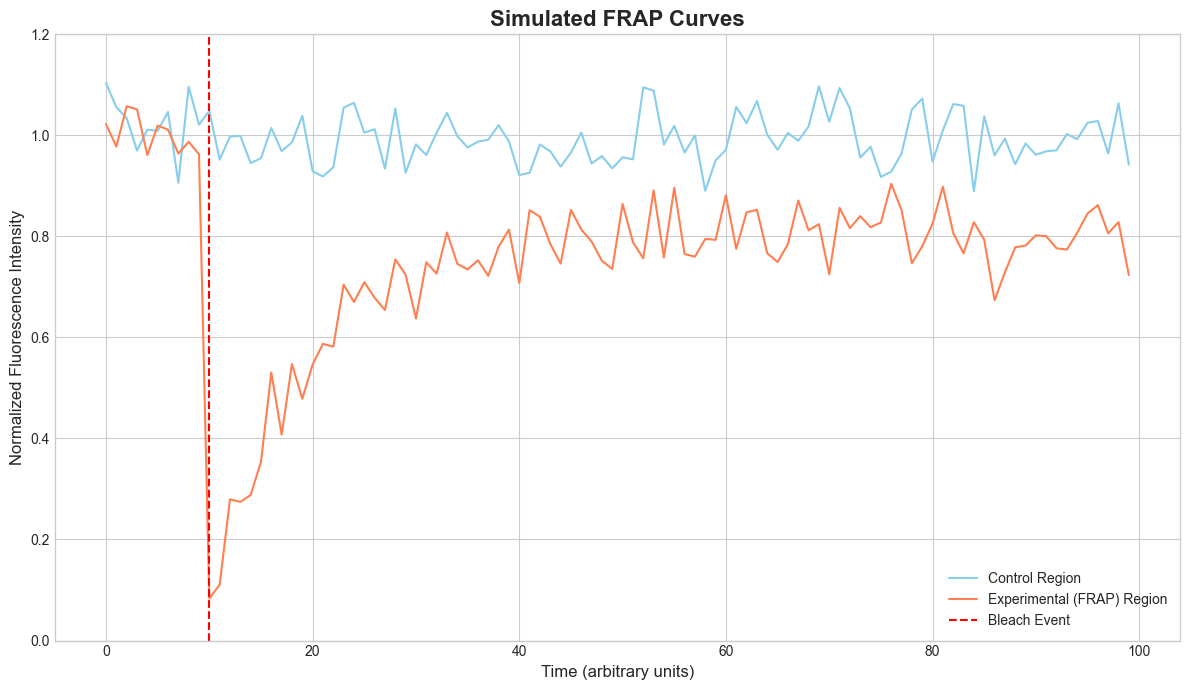

In [14]:
print("--- FRAP Curve Simulator ---")


total_points = 100
pre_bleach_points = 10
mobile_fraction = 0.8
tau = 0.1
photobleach_decay_rate = 0.0001
noise_sigma = 0.05

# Simulate the data
time, control_signal, exp_signal = simulate_frap(
    total_points=total_points,
    pre_bleach_points=pre_bleach_points,
    mobile_fraction=mobile_fraction,
    tau=tau,
    photobleach_decay_rate=photobleach_decay_rate,
    noise_sigma=noise_sigma
)

# Plot the results
plot_frap_curves(time, control_signal, exp_signal, pre_bleach_points)

roiData = {
    'timepoint': time,
    'timpoint_frap': time - pre_bleach_points,
    'timestamp': time,
    'timestamp_frap': time - pre_bleach_points,
    'bleach': exp_signal,
    'control_roi' : control_signal
}
roiData = pd.DataFrame(roiData)
frap_experiment = {
    'bleach_frame' : [pre_bleach_points],
    'wcell_corr': [False],
    'dt': [1],
    'nframes': [total_points]    
}
frap_experiment = pd.DataFrame(frap_experiment)

[photobleaching_corr] Calculating photobleaching from imaging using control_roi reference region
	using data from frame 13 onwards (3 after roi bleaching)
[np.float64(0.9918059208969734), 0.1, 0.001]
Fit results:
	offset = 0.9458967351791756
	amplitude: 0.044793680205063434
	tau: 3.1647758406833753e-16
	Fitting error (r2)= -1.7763568394002505e-15
	Fitting goodness (chi2)= 1.885731421547047
Fitting recovery model
Fit results:
	offset = 0.8277983387387071
	amplitude: -0.7547138206859326
	tau: 0.1041505756631811
	Fitting error (r2)= 0.9092450298231016
	Fitting goodness (chi2)= 0.00572614915357551

FRAP results:
	Half maximum = 6.655240992633169 [s]
	Half maximum (GT) = 6.931471805599452 [s]
	Bleach depth 0.08521858694465781
	Gap Ratio= 0.9657482357498464
	Mobile Fraction (uncorrected) = 0.8430983581316669 (0.8142207519292495)


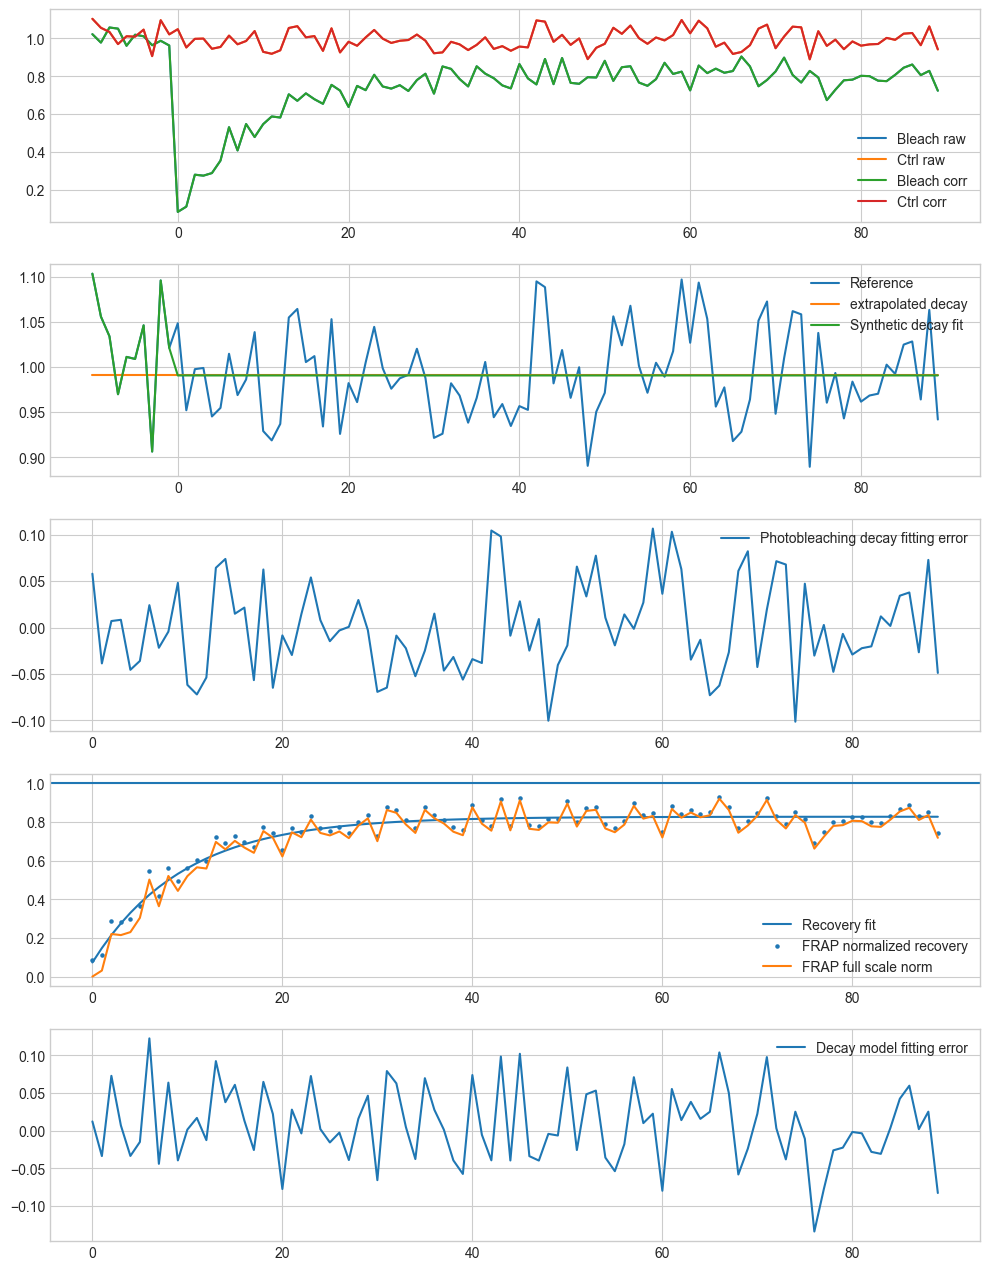

In [15]:
import tools.frap_tools as frap_tools
roiData, frap_experiment = frap_tools.run_FRAP_analysis(roiData, frap_experiment, 1)

#for region in regions.iterrows():
#    print(region)

#roiData, frap_experiment = processing_tools.photobleaching_corr(roiData, 'control_roi' , frap_experiment, delay = 10,exp=1)

#roiData, frap_experiment = processing_tools.pre_bleach_normalization(roiData,'control_roi' , frap_experiment)

#roiData, frap_experiment = processing_tools.fit_recovery_curve(roiData, frap_experiment, exp=2)




print('\nFRAP results:')
if frap_experiment['recovery_model'].item()==1:
    print('\tHalf maximum = ' + str(frap_experiment['half_max'].item()) + ' [s]')
    print('\tHalf maximum (GT) = ' + str(np.log(2)/tau) + ' [s]')
else:
    print('\tHalf maximum = ' + str(frap_experiment['half_max'].item()) + ' [s]')
    print('\tHalf maximum slow = ' + str(frap_experiment['half_max_slow'].item()) + ' [s]')
    print('\tHalf maximum fast = ' + str(frap_experiment['half_max_fast'].item()) + ' [s]')
    
print('\tBleach depth ' + str(frap_experiment['bleach_depth'].item()))
print('\tGap Ratio= ' + str(frap_experiment['gap_ratio'].item()))
print('\tMobile Fraction (uncorrected) = ' + str(frap_experiment['mob_corr'].item()) + ' (' + str(frap_experiment['mob'].item()) + ')')



#rect = patches.Rectangle((100, 100), 50, 50, linewidth=1, edgecolor='r', facecolor="none") 
  

# Add the patch to the Axes 
fig, ax = plt.subplots(5, figsize=(12, 16)) 

#Display sample image after photobleaching


#Plot raw and bleaching corrected data
ax[0].plot(roiData['timestamp_frap'],roiData['bleach'])
ax[0].plot(roiData['timestamp_frap'],roiData['reference'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[0].plot(roiData['timestamp_frap'],roiData['bleach_photo_corr'])
ax[0].plot(roiData['timestamp_frap'],roiData['reference_photo_corr'])
#ax[1].plot(roiData['timestamp_frap'],roiData['reference_synth'])

ax[0].legend(['Bleach raw', 'Ctrl raw', 'Bleach corr', 'Ctrl corr'])

#Plot photobleaching correction
ax[1].plot(roiData['timestamp_frap'],roiData['reference'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference_decay_curve'])
ax[1].plot(roiData['timestamp_frap'],roiData['reference_synth'])
ax[1].legend(['Reference', 'extrapolated decay', 'Synthetic decay fit'])

#Plot photobleaching correction estimation error
ax[2].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::], 
           roiData['reference'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['reference_decay_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[2].legend(['Photobleaching decay fitting error'])

#Plot photobleaching error
#ax[4].scatter(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
#           roiData['bleach_photo_corr_norm'].iloc[frap_experiment.bleach_frame.item() ::], s=5)
#ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           #roiData['reference_photo_corr_norm'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['bleach_recovery_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].scatter(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['frap_norm'].iloc[frap_experiment.bleach_frame.item() ::], s=5)
ax[3].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
           roiData['frap_fullscale_norm'].iloc[frap_experiment.bleach_frame.item() ::])
ax[3].axhline(y=1) 
ax[3].legend([ 'Recovery fit','FRAP normalized recovery', 'FRAP full scale norm'])
#ax[4].legend(['Normalized recovery', 'Recovery fit','FRAP norm', 'FRAP full scale norm'])

ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::],
          roiData['frap_norm'].iloc[frap_experiment.bleach_frame.item() ::]-roiData['bleach_recovery_curve'].iloc[frap_experiment.bleach_frame.item() ::])
ax[4].legend(['Decay model fitting error'])
#ax[4].plot(roiData['timestamp_frap'].iloc[frap_experiment.bleach_frame.item() ::], 
#           roiData['control_wcell'].iloc[frap_experiment.bleach_frame.item() ::])
plt.show() 